In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import struc_dist.rna_utils as ru

In [3]:

def get_min_mean(fam):
    min_dists = ru.table_min_inter_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def get_avg_min_mean(fam):
    min_dists = ru.table_avg_min_intra_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def make_long_df(df, value_name="Distancia"):
    df_long = df.reset_index().melt(
        id_vars="index", var_name="Familia", value_name=value_name
    )
    df_long.rename(columns={"index": "Condición"}, inplace=True)
    return df_long


def reorder_df_by_diagonal(df, fixed_order=True):
    fixed_labels = [
    "telomerase",
    "5s",
    "tRNA",
    "tmRNA",
    "RNaseP",
    "23s",
    "grp1",
    "srp",
    "16s",
    ]
    # Asegurarse de que el índice y las columnas coincidan
    common = df.index.intersection(df.columns)
    # Obtener los valores diagonales
    diagonal = df.loc[common, common].values.diagonal()
    # Crear un orden basado en la diagonal (de mayor a menor)
    ordered_labels = common[np.argsort(-diagonal)]  # el "-" es para ordenar descendente
    # Reordenar el DataFrame
    if fixed_order:
        df_sorted = df.loc[fixed_labels, fixed_labels]
    else:
        df_sorted = df.loc[ordered_labels, ordered_labels]
    return df_sorted

def get_dfs(dists_paths, META_PATH):
    """
    Carga y procesa las matrices de distancia estructural filtradas.
    """
    dists = ["full", "dist100", "dist200", "dist400"]
    dfs = {}
    meta = {}
    fams = {}
    mins = {}
    means = {}
    avg_mins = {}
    for d in dists:
        dfs[d], meta[d] = ru.load_and_align(corr_path=dists_paths[d], meta_path=META_PATH)
    dfs_ref = dfs["full"].copy()
    for d in dists:
        dfs[d] = dfs[d] / dfs_ref.max().max()
        fams[d] = ru.build_inter_fam_corrs(dfs[d], meta[d])
        mins[d], means[d] = get_min_mean(fams[d])
        avg_mins[d], _ = get_avg_min_mean(fams[d])
        mins[d] = reorder_df_by_diagonal(mins[d], fixed_order=True)
        means[d] = reorder_df_by_diagonal(means[d], fixed_order=True)
        avg_mins[d] = reorder_df_by_diagonal(avg_mins[d], fixed_order=True)
        
    return mins, means, avg_mins
    

In [4]:


DATA_PATH    = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/"

DIST_PATH    = DATA_PATH + "rnadist_f_all.h5"
SORTS100_PATH = DATA_PATH + "rnadist_filtered100.h5"
SORTS200_PATH = DATA_PATH + "rnadist_filtered200.h5"
SORTS400_PATH = DATA_PATH + "rnadist_filtered400.h5"


CLUSS100_PATH = DATA_PATH + "hc_filtered100.h5"
CLUSS200_PATH = DATA_PATH + "hc_filtered200.h5"
CLUSS400_PATH = DATA_PATH + "hc_filtered400.h5"

RANDS100_PATH = DATA_PATH + "samples_filtered100.h5"
RANDS200_PATH = DATA_PATH + "samples_filtered200.h5"
RANDS400_PATH = DATA_PATH + "samples_filtered400.h5"
META_PATH    = DATA_PATH + "sources/ArchiveII_with_prob_and_motiv.csv"


dists_sortS_paths = {
    "full": DIST_PATH,
    "dist100": SORTS100_PATH,
    "dist200": SORTS200_PATH,
    "dist400": SORTS400_PATH
}
dist_clusS_paths = {
    "full": DIST_PATH,
    "dist100": CLUSS100_PATH,
    "dist200": CLUSS200_PATH,
    "dist400": CLUSS400_PATH
}
dist_randS_paths = {
    "full": DIST_PATH,
    "dist100": RANDS100_PATH,
    "dist200": RANDS200_PATH,
    "dist400": RANDS400_PATH
}

sortS_mins, sortS_means, sortS_avg_mins = get_dfs(dists_sortS_paths, META_PATH)
clusS_mins, clusS_means, clusS_avg_mins = get_dfs(dist_clusS_paths, META_PATH)
randS_mins, randS_means, randS_avg_mins = get_dfs(dist_randS_paths, META_PATH)

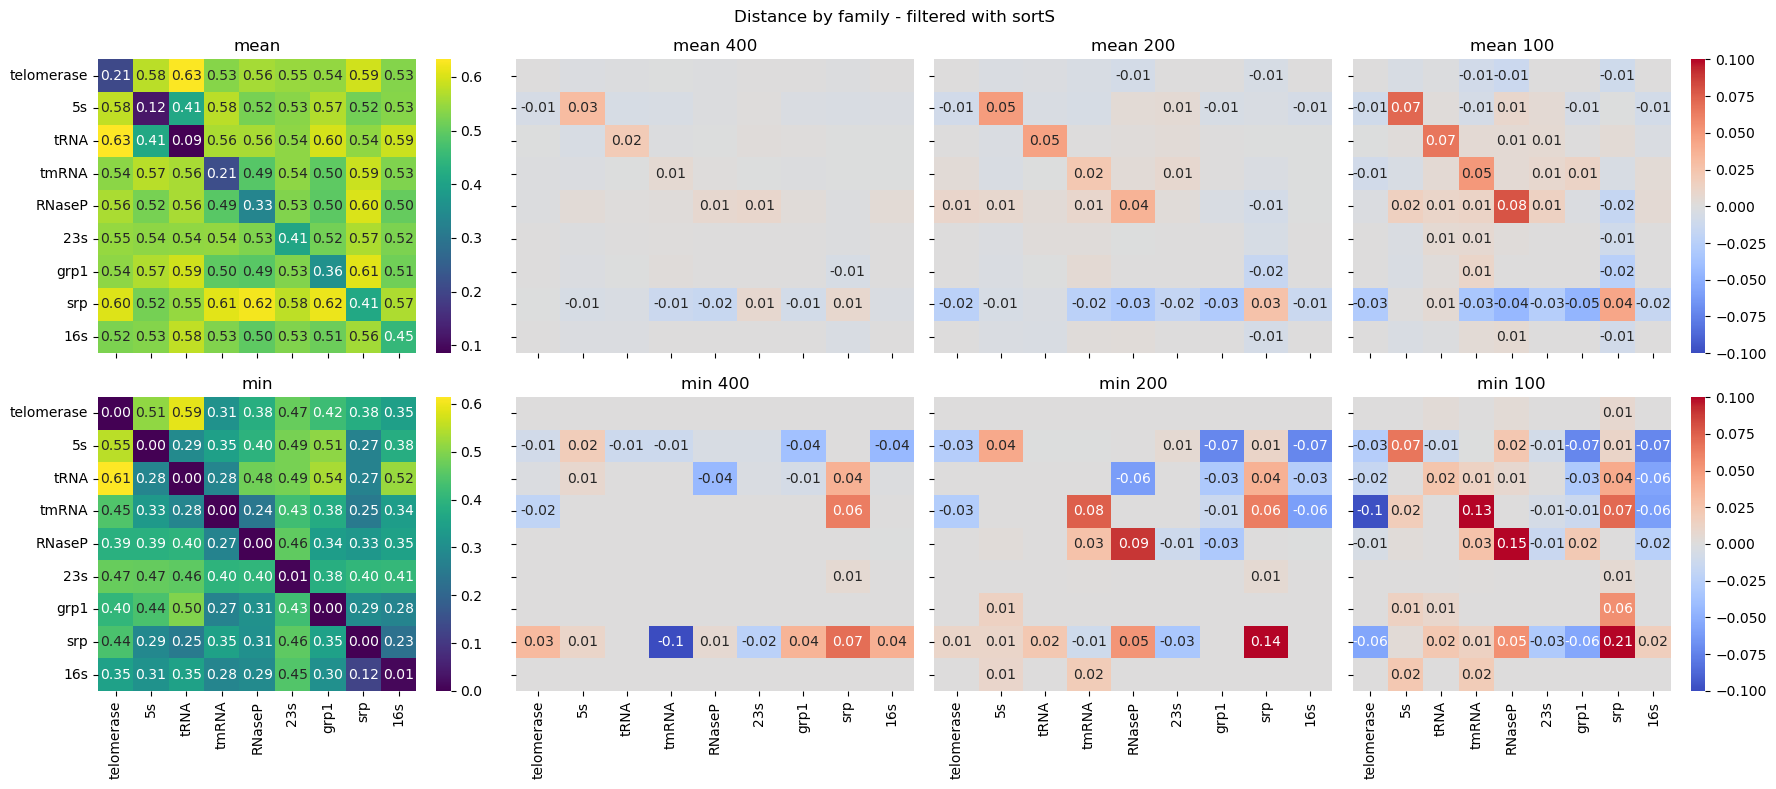

In [5]:
def annot_no_zeros(mat, fmt=".2f"):
    """Devuelve matriz de strings, con '' cuando el valor es 0."""
    return np.where(np.round(mat, 2) == 0, "", mat.astype(float).round(2).astype(str))


fig, ax = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
sns.heatmap(sortS_means["full"], annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0])

ss_delta_mean_400 = sortS_means["dist400"] - sortS_means["full"]
delta_mean_200 = sortS_means["dist200"] - sortS_means["full"]
delta_mean_100 = sortS_means["dist100"] - sortS_means["full"]
sns.heatmap(ss_delta_mean_400, annot=  annot_no_zeros(ss_delta_mean_400), fmt="", cmap="coolwarm", ax=ax[0,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_mean_200, annot=  annot_no_zeros(delta_mean_200), fmt="", cmap="coolwarm", ax=ax[0,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_mean_100, annot=  annot_no_zeros(delta_mean_100), fmt="", cmap="coolwarm", ax=ax[0,3], vmin=-0.1, vmax=0.1)


sns.heatmap(sortS_mins["full"], annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0])

ss_delta_min_400 = sortS_mins["dist400"] - sortS_mins["full"]
delta_min_200 = sortS_mins["dist200"] - sortS_mins["full"]
delta_min_100 = sortS_mins["dist100"] - sortS_mins["full"]
sns.heatmap(ss_delta_min_400, annot= annot_no_zeros(ss_delta_min_400), fmt="", cmap="coolwarm", ax=ax[1,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_min_200, annot= annot_no_zeros(delta_min_200), fmt="", cmap="coolwarm", ax=ax[1,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_min_100, annot= annot_no_zeros(delta_min_100), fmt="", cmap="coolwarm", ax=ax[1,3], vmin=-0.1, vmax=0.1)


ax[0,0].set_title("mean")
ax[0,1].set_title("mean 400")
ax[0,2].set_title("mean 200")
ax[0,3].set_title("mean 100")
ax[1,0].set_title("min")
ax[1,1].set_title("min 400")
ax[1,2].set_title("min 200")
ax[1,3].set_title("min 100")
fig.suptitle("Distance by family - filtered with sortS")
fig.tight_layout()
plt.show()

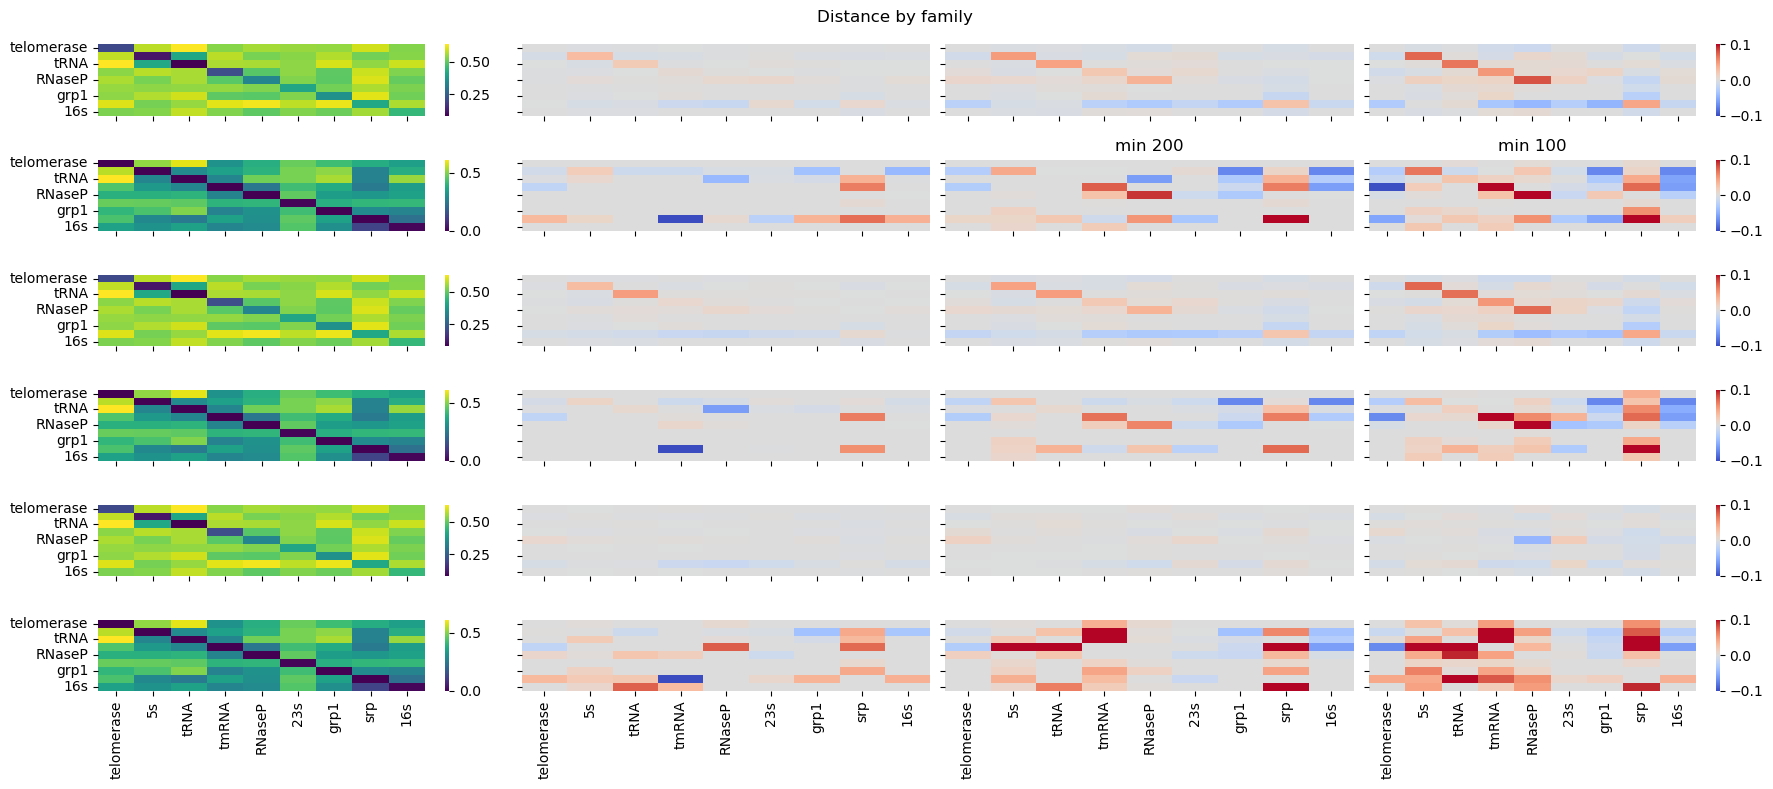

In [6]:
fig, ax = plt.subplots(3*2, 4, figsize=(18, 8), sharex=True, sharey=True)

sns.heatmap(sortS_means["full"], annot=False, cmap="viridis", ax=ax[0,0])

ss_delta_mean_400 = sortS_means["dist400"] - sortS_means["full"]
ss_delta_mean_200 = sortS_means["dist200"] - sortS_means["full"]
ss_delta_mean_100 = sortS_means["dist100"] - sortS_means["full"]
sns.heatmap(ss_delta_mean_400, annot=False, cmap="coolwarm", ax=ax[0,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(ss_delta_mean_200, annot=False, cmap="coolwarm", ax=ax[0,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(ss_delta_mean_100, annot=False, cmap="coolwarm", ax=ax[0,3], vmin=-0.1, vmax=0.1)


sns.heatmap(sortS_mins["full"], annot=False,  cmap="viridis", ax=ax[1,0])

ss_delta_min_400 = sortS_mins["dist400"] - sortS_mins["full"]
ss_delta_min_200 = sortS_mins["dist200"] - sortS_mins["full"]
ss_delta_min_100 = sortS_mins["dist100"] - sortS_mins["full"]
sns.heatmap(ss_delta_min_400, annot=False, cmap="coolwarm", ax=ax[1,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(ss_delta_min_200, annot=False, cmap="coolwarm", ax=ax[1,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(ss_delta_min_100, annot=False, cmap="coolwarm", ax=ax[1,3], vmin=-0.1, vmax=0.1)


sns.heatmap(clusS_means["full"], annot=False, cmap="viridis", ax=ax[2,0])

clusS_delta_mean_400 = clusS_means["dist400"] - clusS_means["full"]
clusS_delta_mean_200 = clusS_means["dist200"] - clusS_means["full"]
clusS_delta_mean_100 = clusS_means["dist100"] - clusS_means["full"]
sns.heatmap(clusS_delta_mean_400, annot=False, cmap="coolwarm", ax=ax[2,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(clusS_delta_mean_200, annot=False, cmap="coolwarm", ax=ax[2,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(clusS_delta_mean_100, annot=False, cmap="coolwarm", ax=ax[2,3], vmin=-0.1, vmax=0.1)


sns.heatmap(clusS_mins["full"], annot=False,  cmap="viridis", ax=ax[3,0])

clusS_delta_min_400 = clusS_mins["dist400"] - clusS_mins["full"]
clusS_delta_min_200 = clusS_mins["dist200"] - clusS_mins["full"]
clusS_delta_min_100 = clusS_mins["dist100"] - clusS_mins["full"]
sns.heatmap(clusS_delta_min_400, annot=False, cmap="coolwarm", ax=ax[3,1], cbar=False, vmin=-0.1, vmax= 0.1)
sns.heatmap(clusS_delta_min_200, annot=False, cmap="coolwarm", ax=ax[3,2], cbar=False, vmin=-0.1, vmax= 0.1)
sns.heatmap(clusS_delta_min_100, annot=False, cmap="coolwarm", ax=ax[3,3], vmin=-0.1, vmax= 0.1)


sns.heatmap(randS_means["full"], annot=False, cmap="viridis", ax=ax[4,0])

sns.heatmap(randS_mins["full"], annot=False,  cmap="viridis", ax=ax[5,0])

randS_delta_mean_400 = randS_means["dist400"] - randS_means["full"]
randS_delta_mean_200 = randS_means["dist200"] - randS_means["full"]
randS_delta_mean_100 = randS_means["dist100"] - randS_means["full"]
sns.heatmap(randS_delta_mean_400, annot=False, cmap="coolwarm", ax=ax[4,1], cbar=False, vmin=-0.1, vmax= 0.1)
sns.heatmap(randS_delta_mean_200, annot=False, cmap="coolwarm", ax=ax[4,2], cbar=False, vmin=-0.1, vmax= 0.1)
sns.heatmap(randS_delta_mean_100, annot=False, cmap="coolwarm", ax=ax[4,3], vmin=-0.1, vmax= 0.1)

randS_delta_min_400 = randS_mins["dist400"] - randS_mins["full"]
randS_delta_min_200 = randS_mins["dist200"] - randS_mins["full"]
randS_delta_min_100 = randS_mins["dist100"] - randS_mins["full"]
sns.heatmap(randS_delta_min_400, annot=False, cmap="coolwarm", ax=ax[5,1], cbar=False, vmin=- 0.1, vmax= 0.1)
sns.heatmap(randS_delta_min_200, annot=False, cmap="coolwarm", ax=ax[5,2], cbar=False, vmin=- 0.1, vmax= 0.1)
sns.heatmap(randS_delta_min_100, annot=False, cmap="coolwarm", ax=ax[5,3], vmin=- 0.1, vmax= 0.1)
ax[1,2].set_title("min 200")
ax[1,3].set_title("min 100")
fig.suptitle("Distance by family")


fig.tight_layout()
plt.show()

/tmp/ipykernel_3079699/426451205.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0,0,0.90,1])


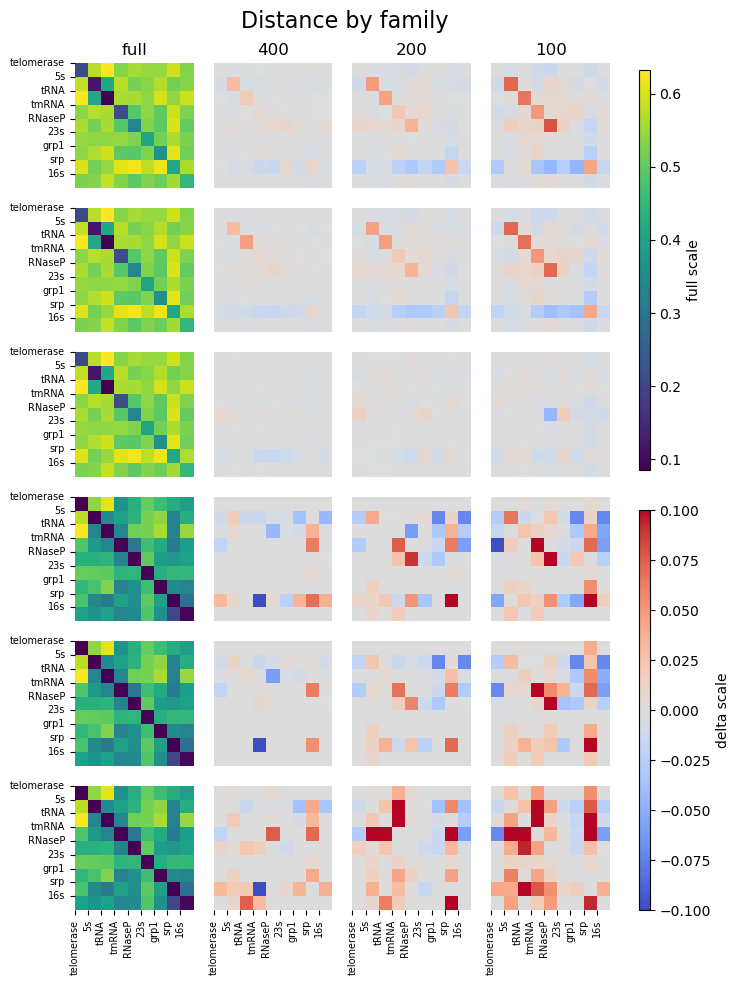

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(6, 4, figsize=(7, 10))

rows = [
    ("means sortS", sortS_means),
    ("means clusS", clusS_means),
    ("means randS", randS_means),
    ("mins sortS",  sortS_mins),
    ("mins clusS",  clusS_mins),
    ("mins randS",  randS_mins),
]

dists = ["dist400", "dist200", "dist100"]

full_mappable = None
delta_mappable = None


def plot_row(data_dict, row_idx, row_label):
    global full_mappable, delta_mappable

    # Etiqueta de fila
    ax[row_idx, 0].set_ylabel(row_label, fontsize=12, rotation=0,
                              labelpad=40, va="center")

    # FULL
    hm_full = sns.heatmap(
        data_dict["full"], annot=False, cmap="viridis",
        ax=ax[row_idx, 0], cbar=False
    )
    if full_mappable is None:
        full_mappable = hm_full.get_children()[0]

    # DELTAS
    for j, dist in enumerate(dists, start=1):
        delta = data_dict[dist] - data_dict["full"]
        hm_delta = sns.heatmap(
            delta, annot=False, cmap="coolwarm",
            ax=ax[row_idx, j], vmin=-0.1, vmax=0.1, cbar=False
        )
        if delta_mappable is None:
            delta_mappable = hm_delta.get_children()[0]


# ---- 1) DIBUJAR TODO ---
for i, (label_short, data_dict) in enumerate(rows):
    plot_row(data_dict, i, label_short)

# ---- 2) AHORA restaurar ticks EXTERNOS ----

# Y ticks solo en primera columna
for i in range(6):
    data = rows[i][1]["full"]
    ax[i, 0].set_yticks(range(data.shape[0]))
    ax[i, 0].set_yticklabels(data.index, fontsize=7, rotation=0)

# X ticks solo en última fila
last_row = 5
for j in range(4):
    data = rows[last_row][1]["full"]
    ax[last_row, j].set_xticks(range(data.shape[1]))
    ax[last_row, j].set_xticklabels(data.columns, fontsize=7, rotation=90)

# Eliminar ticks del resto
for i in range(6):
    for j in range(4):
        if not (j == 0 or i == last_row):
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            
for i in range(5):  
            ax[i, 0].set_xticks([]) 
for j in range(1,4):  
            ax[-1, j].set_yticks([]) 
# ---- 3) Títulos de columna ----
col_titles = ["full","400", "200", "100"]
for j, title in enumerate(col_titles):
    ax[0, j].set_title(title, fontsize=12) 

# ---- 4) Colorbars únicas ----
cbar_ax1 = fig.add_axes([0.92, 0.52, 0.015, 0.40])
cbar_ax2 = fig.add_axes([0.92, 0.08, 0.015, 0.40])

fig.colorbar(full_mappable, cax=cbar_ax1).set_label("full scale")
fig.colorbar(delta_mappable, cax=cbar_ax2).set_label("delta scale")

fig.suptitle("Distance by family", fontsize=16)
fig.tight_layout(rect=[0,0,0.90,1])
plt.savefig("./inter_dist.svg")
plt.show()

/tmp/ipykernel_200845/898153931.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0,0,0.90,1])


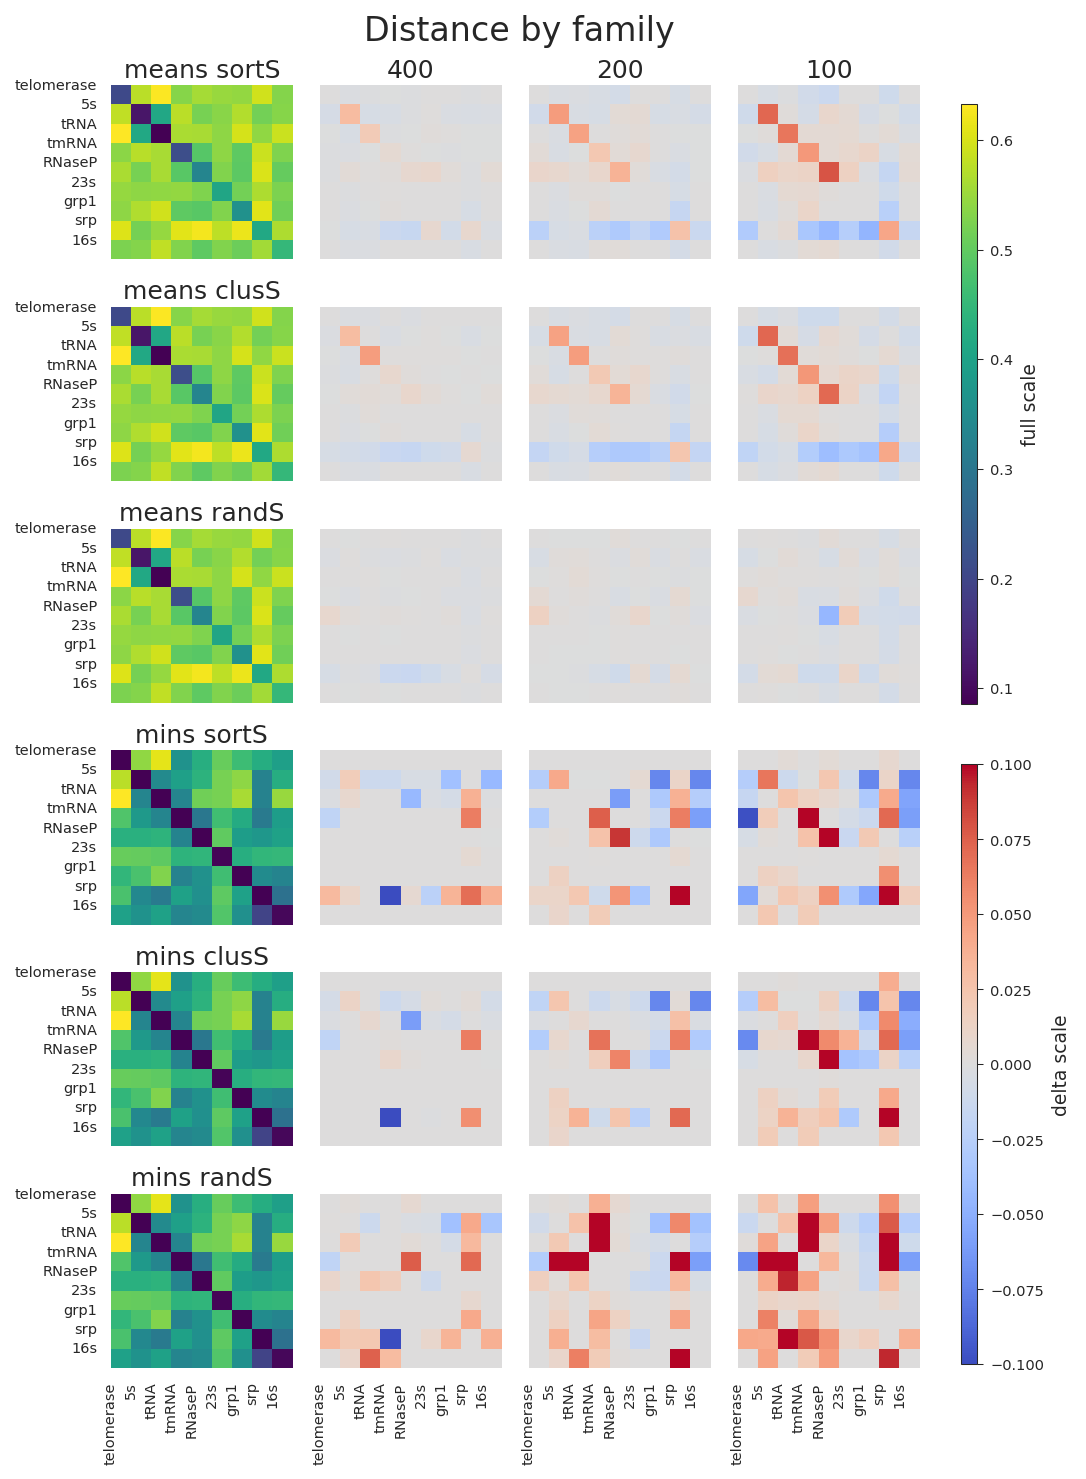

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns 

# Paletas tipo Nature
import seaborn as sns
sns.set_palette("viridis")
sns.set_style("white")   # fondo blanco

fig, ax = plt.subplots(6, 4, figsize=(7, 10))

rows = [
    ("means sortS", sortS_means),
    ("means clusS", clusS_means),
    ("means randS", randS_means),
    ("mins sortS",  sortS_mins),
    ("mins clusS",  clusS_mins),
    ("mins randS",  randS_mins),
]

dists = ["dist400", "dist200", "dist100"]

full_mappable = None
delta_mappable = None


def plot_row(data_dict, row_idx, row_label):
    global full_mappable, delta_mappable

    # Etiqueta de fila
    ax[row_idx, 0].set_ylabel(row_label, fontsize=12, rotation=0,
                              labelpad=40, va="center")

    # FULL
    hm_full = sns.heatmap(
        data_dict["full"], annot=False, cmap="viridis",
        ax=ax[row_idx, 0], cbar=False
    )
    if full_mappable is None:
        full_mappable = hm_full.get_children()[0]

    # DELTAS
    for j, dist in enumerate(dists, start=1):
        delta = data_dict[dist] - data_dict["full"]
        hm_delta = sns.heatmap(
            delta, annot=False, cmap="coolwarm",
            ax=ax[row_idx, j], vmin=-0.1, vmax=0.1, cbar=False
        )
        if delta_mappable is None:
            delta_mappable = hm_delta.get_children()[0]


# ---- 1) DIBUJAR TODO ---
for i, (label_short, data_dict) in enumerate(rows):
    plot_row(data_dict, i, label_short)

# ---- 2) AHORA restaurar ticks EXTERNOS ----

# Y ticks solo en primera columna
for i in range(6):
    data = rows[i][1]["full"]
    ax[i, 0].set_yticks(range(data.shape[0]))
    ax[i, 0].set_yticklabels(data.index, fontsize=7, rotation=0)

# X ticks solo en última fila
last_row = 5
for j in range(4):
    data = rows[last_row][1]["full"]
    ax[last_row, j].set_xticks(range(data.shape[1]))
    ax[last_row, j].set_xticklabels(data.columns, fontsize=7, rotation=90)

# Eliminar ticks del resto
for i in range(6):
    for j in range(4):
        if not (j == 0 or i == last_row):
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            
for i in range(5):  
            ax[i, 0].set_xticks([]) 
for j in range(1,4):  
            ax[-1, j].set_yticks([]) 
# ---- 3) Títulos de columna ----
col_titles = ["400", "200", "100"]
for j, title in enumerate(col_titles):
    ax[0, j+1].set_title(title, fontsize=12)

for i, title in enumerate(rows):
    ax[i, 0].set_title(title[0], fontsize=12)

# ---- 4) Colorbars únicas ----
cbar_ax1 = fig.add_axes([0.92, 0.52, 0.015, 0.40])
cbar_ax2 = fig.add_axes([0.92, 0.08, 0.015, 0.40])

fig.colorbar(full_mappable, cax=cbar_ax1).set_label("full scale")
fig.colorbar(delta_mappable, cax=cbar_ax2).set_label("delta scale")

fig.suptitle("Distance by family", fontsize=16)
fig.tight_layout(rect=[0,0,0.90,1])
plt.show()


TypeError: 'dict_keys' object is not subscriptable

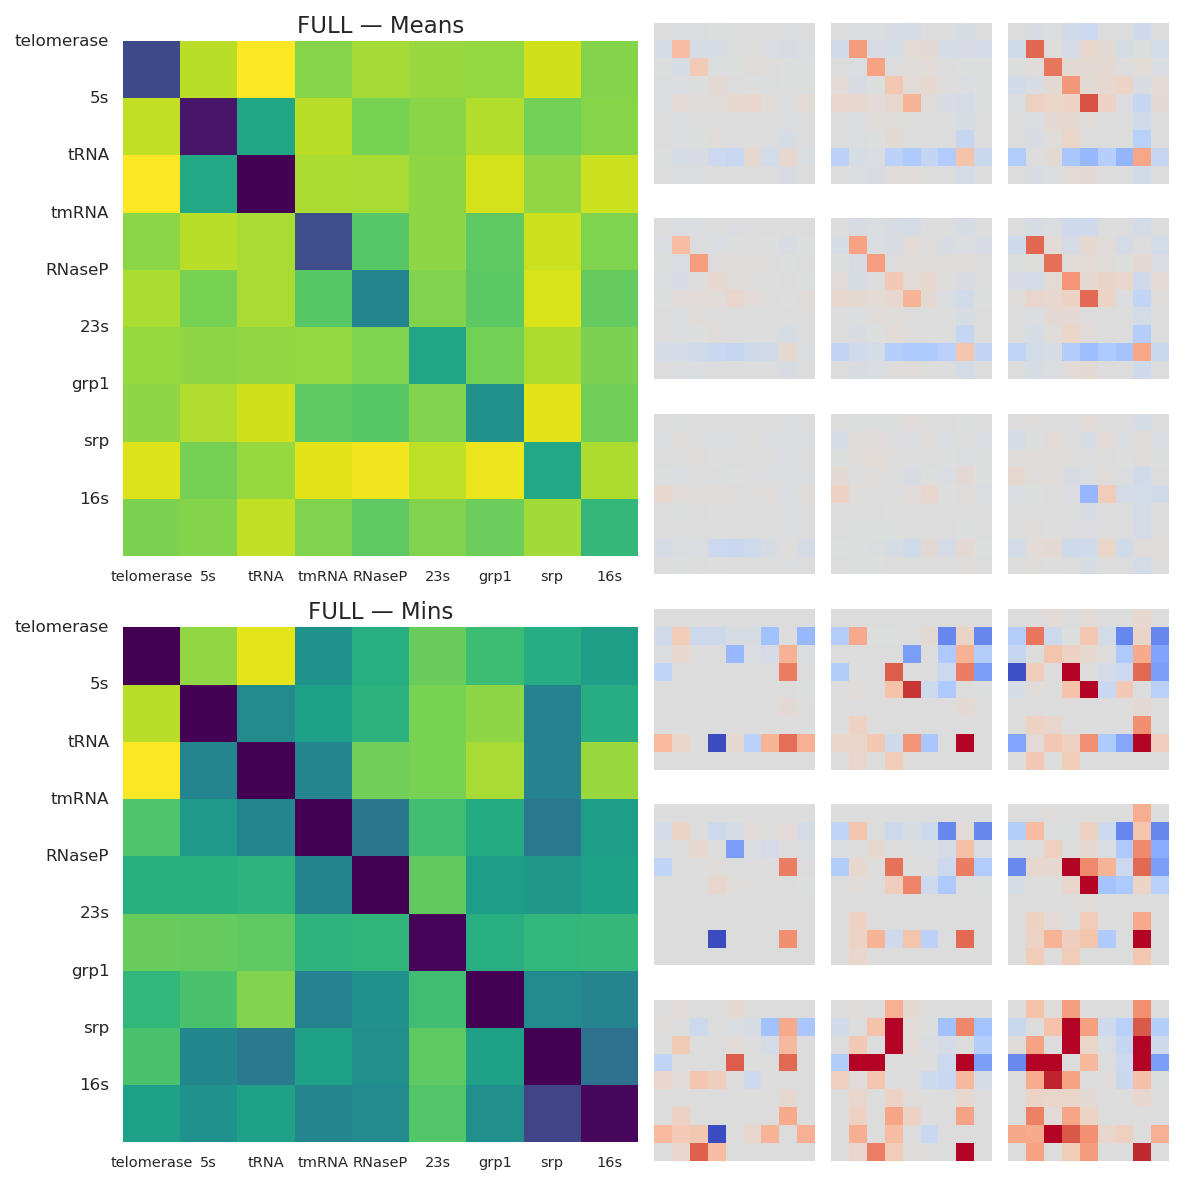

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ---- PRESET estilo Nature ----
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.linewidth": 0.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

sns.set_style("white")

# ---- FIGURA NUEVA: 6 × 6 ----
fig = plt.figure(figsize=(9, 10))
gs = fig.add_gridspec(6, 6, wspace=0.1, hspace=0.1)

# datos
dists = ["dist400", "dist200", "dist100"]
variants = ["sortS", "clusS", "randS"]

# ---- función para un bloque superior/inferior ----
def plot_block(full_matrix, all_dicts, row_offset):

    # LEFT: FULL
    ax_full = fig.add_subplot(gs[row_offset:row_offset+3, 0:3])
    hm_full = sns.heatmap(
        full_matrix, cmap="viridis", cbar=False,
        ax=ax_full, square=True
    )

    # RIGHT: 3×3 grid
    axes_dist = []
    for i, var in enumerate(variants):
        for j, dist in enumerate(dists):
            ax = fig.add_subplot(gs[row_offset+i, 3+j])
            delta = all_dicts[var][dist] - full_matrix
            sns.heatmap(
                delta, cmap="coolwarm", vmin=-0.1, vmax=0.1,
                cbar=False, ax=ax, square=True
            )
            axes_dist.append(ax)

    return ax_full, axes_dist


# ---- BLOQUE SUPERIOR: MEANS ----
full_mean = sortS_means["full"]  # el mismo para sort/clus/rand
dict_means = {
    "sortS": sortS_means,
    "clusS": clusS_means,
    "randS": randS_means,
}
ax_full_mean, ax_dist_mean = plot_block(full_mean, dict_means, row_offset=0)

# ---- BLOQUE INFERIOR: MINS ----
full_min = sortS_mins["full"]  # el mismo para sort/clus/rand
dict_mins = {
    "sortS": sortS_mins,
    "clusS": clusS_mins,
    "randS": randS_mins,
}
ax_full_min, ax_dist_min = plot_block(full_min, dict_mins, row_offset=3)


# ---- TICKS SOLO EN LOS BORDES EXTERNOS ----

# LEFT BLOCKS y-axis ticks
for ax in [ax_full_mean, ax_full_min]:
    ax.set_yticks(range(full_mean.shape[0]))
    ax.set_yticklabels(full_mean.index, rotation=0, fontsize=8)

# RIGHT BLOCKS: solo labels en la última fila
for ax in ax_dist_min:
    ax.set_xticks(range(full_mean.shape[1]))
    ax.set_xticklabels(full_mean.columns, rotation=90, fontsize=7)

# Quitar ticks del resto
for ax in fig.get_axes():
    if ax not in [ax_full_mean, ax_full_min] and ax not in [ax_full_mean, ax_full_min]:
        ax.set_xticks([])
        ax.set_yticks([]) 
        

# ---- TÍTULOS ----
ax_full_mean.set_title("FULL — Means", fontsize=11)
ax_full_min.set_title("FULL — Mins", fontsize=11)
ax_dist_mean[0].set_ylabel(dict_means.keys()[0], fontsize=11)
ax_dist_mean[1].set_ylabel(dict_means.keys()[1], fontsize=11)
ax_dist_mean[2].set_ylabel(dict_means.keys()[2], fontsize=11)

ax_dist_min[0].set_ylabel(dict_mins.keys()[0], fontsize=11)
ax_dist_min[1].set_ylabel(dict_mins.keys()[1], fontsize=11)
ax_dist_min[2].set_ylabel(dict_mins.keys()[2], fontsize=11)

# Column titles over the DIST heatmaps
for j, dist in enumerate(dists):
    ax = fig.add_subplot(gs[0, 3+j])
    ax.set_title(dist.replace("dist", ""), fontsize=10)
    ax.axis("off")

# Row titles for sort/clus/rand
for i, var in enumerate(variants):
    ax = fig.add_subplot(gs[i, 3])
    ax.set_ylabel([var], rotation=0, labelpad=25, fontsize=10)
    ax.axis("off")

# ---- COLORBARS ----
cax_full = fig.add_axes([0.92, 0.58, 0.015, 0.30])
cax_delta = fig.add_axes([0.92, 0.15, 0.015, 0.30])

fig.colorbar(
    fig.axes[0].collections[0],
    cax=cax_full
).set_label("full scale")

fig.colorbar(
    fig.axes[1].collections[0],
    cax=cax_delta
).set_label("delta scale")


fig.suptitle("Distance analysis by family", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()
